# Stage 2 P-Wave Picking Using a 1D CNN

The Stage 2 model estimates the temporal location of the P-wave arrival within the complete three-component seismic waveform. The INSTANCE annotated P-wave arrival samples are used as reference targets during training and evaluation.

The model processes the full 120-second waveform and produces a time-dependent P-wave detection score. The predicted P-wave arrival is obtained from the location of the maximum model response and is compared with the annotated P-wave arrival.

## Load earthquake metadata and waveform data

The INSTANCE earthquake metadata and corresponding HDF5 waveform recordings are loaded for construction of the P-wave picking dataset. The metadata provide the reference P-wave arrival samples used for supervised labeling and evaluation.

In [47]:
import numpy as np
import pandas as pd
import h5py
from pathlib import Path
import matplotlib.pyplot as plt

project_root = Path.cwd().parent

metadata_path = (
    project_root
    / "data"
    / "sample"
    / "metadata"
    / "metadata_Instance_events_10k.csv"
)

hdf5_path = (
    project_root
    / "data"
    / "sample"
    / "data"
    / "Instance_events_counts_10k.hdf5"
)

metadata = pd.read_csv(metadata_path)

print("Metadata shape:", metadata.shape)

print(
    metadata[
        [
            "trace_name",
            "source_id",
            "trace_dt_s",
            "trace_P_arrival_sample"
        ]
    ].head()
)

Metadata shape: (10000, 115)
             trace_name  source_id  trace_dt_s  trace_P_arrival_sample
0  11030611.IV.OFFI..HH   11030611        0.01                    1735
1  11030611.IV.PIEI..HH   11030611        0.01                    1876
2  11030611.IV.PIEI..HN   11030611        0.01                    1889
3  11030611.IV.RM33..EH   11030611        0.01                    1678
4  11030611.IV.RM33..HN   11030611        0.01                    1610


## Create event-level dataset splits

The earthquake recordings are divided into training, validation, and test sets using `source_id` as the grouping variable. All waveform recordings belonging to the same earthquake source are assigned to a single split to prevent event-level data leakage.

In [48]:
from sklearn.model_selection import GroupShuffleSplit

metadata = metadata.reset_index(drop=True)

gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.30,
    random_state=42
)

train_idx, temp_idx = next(
    gss.split(
        metadata,
        groups=metadata["source_id"]
    )
)

train_metadata = metadata.iloc[train_idx].reset_index(drop=True)
temp_metadata = metadata.iloc[temp_idx].reset_index(drop=True)

gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.50,
    random_state=42
)

val_idx, test_idx = next(
    gss.split(
        temp_metadata,
        groups=temp_metadata["source_id"]
    )
)

val_metadata = temp_metadata.iloc[val_idx].reset_index(drop=True)
test_metadata = temp_metadata.iloc[test_idx].reset_index(drop=True)

print("Train:", len(train_metadata))
print("Validation:", len(val_metadata))
print("Test:", len(test_metadata))

Train: 6761
Validation: 1593
Test: 1646


## Verify event-level separation

The event identifiers are checked to ensure that no earthquake source occurs in more than one dataset split.

In [49]:
train_sources = set(train_metadata["source_id"])
val_sources = set(val_metadata["source_id"])
test_sources = set(test_metadata["source_id"])

print("Train ∩ Validation:", len(train_sources & val_sources))
print("Train ∩ Test:", len(train_sources & test_sources))
print("Validation ∩ Test:", len(val_sources & test_sources))

Train ∩ Validation: 0
Train ∩ Test: 0
Validation ∩ Test: 0


## Create time-localized P-wave targets

The annotated P-wave arrival is represented as a localized target at the original 100 Hz sampling resolution. Each 120-second waveform therefore contains 12,000 temporal prediction positions. A Gaussian target centered on the annotated P-wave sample provides a localized learning signal while allowing small deviations around the reference arrival.

In [50]:
fs = 100.0
n_samples = 12000
sigma_samples = 20  # 0.20 s

print("Sampling rate:", fs, "Hz")
print("Waveform samples:", n_samples)
print("Time resolution:", 1 / fs, "s")

Sampling rate: 100.0 Hz
Waveform samples: 12000
Time resolution: 0.01 s


In [51]:
def create_p_wave_target(
    p_sample,
    n_samples=12000,
    sigma_samples=20
):
    sample_positions = np.arange(
        n_samples,
        dtype=np.float32
    )

    target = np.exp(
        -0.5
        * ((sample_positions - p_sample) /
           sigma_samples) ** 2
    )

    return target

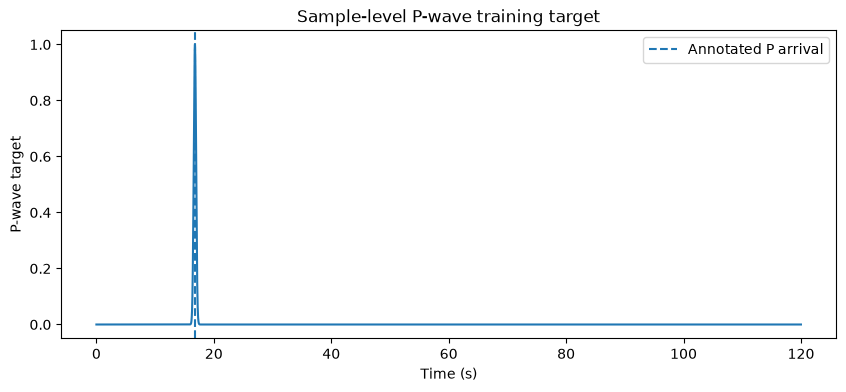

In [52]:
example_target = create_p_wave_target(
    p_sample=1678
)

target_time = np.arange(
    len(example_target)
) / fs

plt.figure(figsize=(10, 4))

plt.plot(
    target_time,
    example_target
)

plt.axvline(
    1678 / fs,
    linestyle="--",
    label="Annotated P arrival"
)

plt.xlabel("Time (s)")
plt.ylabel("P-wave target")
plt.title("Sample-level P-wave training target")
plt.legend()
plt.show()

## Waveform preprocessing

Each three-component earthquake waveform is constant-detrended and filtered using a fourth-order zero-phase Butterworth bandpass filter from 3–20 Hz before being provided to the CNN. The original 100 Hz sampling rate and 12,000-sample waveform length are retained.

In [53]:
from scipy.signal import butter, sosfiltfilt
import numpy as np
import h5py

fs = 100.0

sos = butter(
    4,
    [3.0, 20.0],
    btype="bandpass",
    fs=fs,
    output="sos"
)


def preprocess_trace(waveform):
    processed = np.empty(
        waveform.shape,
        dtype=np.float32
    )

    for component in range(3):

        trace = waveform[component].astype(
            np.float64
        )

        trace = trace - np.mean(trace)

        trace = sosfiltfilt(
            sos,
            trace
        )

        processed[component] = trace.astype(
            np.float32
        )

    return processed

In [54]:
def preprocess_and_save_split(
    split_metadata,
    source_h5_path,
    output_h5_path,
    chunk_size=100
):
    split_metadata = split_metadata.reset_index(drop=True)

    n_records = len(split_metadata)

    with h5py.File(source_h5_path, "r") as source_h5, \
         h5py.File(output_h5_path, "w") as output_h5:

        waveform_dataset = output_h5.create_dataset(
            "waveforms",
            shape=(n_records, 3, 12000),
            dtype="float32",
            chunks=(1, 3, 12000),
            compression="gzip"
        )

        string_dtype = h5py.string_dtype(
            encoding="utf-8"
        )

        trace_dataset = output_h5.create_dataset(
            "trace_name",
            shape=(n_records,),
            dtype=string_dtype
        )

        for start in range(0, n_records, chunk_size):

            end = min(
                start + chunk_size,
                n_records
            )

            batch_metadata = split_metadata.iloc[
                start:end
            ]

            chunk = np.empty(
                (len(batch_metadata), 3, 12000),
                dtype=np.float32
            )

            for j, (_, row) in enumerate(
                batch_metadata.iterrows()
            ):

                trace_name = row["trace_name"]

                waveform = np.asarray(
                    source_h5[f"data/{trace_name}"],
                    dtype=np.float32
                )

                chunk[j] = preprocess_trace(
                    waveform
                )

                trace_dataset[start + j] = trace_name

            waveform_dataset[
                start:end
            ] = chunk

            if end % 1000 == 0 or end == n_records:
                print(f"Processed {end}/{n_records}")

In [57]:
processed_dir = (
    project_root
    / "data"
    / "processed"
    / "stage2_cnn"
)

processed_dir.mkdir(
    parents=True,
    exist_ok=True
)

train_processed_path = (
    processed_dir / "train_waveforms.h5"
)

val_processed_path = (
    processed_dir / "validation_waveforms.h5"
)

test_processed_path = (
    processed_dir / "test_waveforms.h5"
)

In [58]:
preprocess_and_save_split(
    train_metadata,
    hdf5_path,
    train_processed_path
)

Processed 1000/6761
Processed 2000/6761
Processed 3000/6761
Processed 4000/6761
Processed 5000/6761
Processed 6000/6761
Processed 6761/6761


In [59]:
preprocess_and_save_split(
    val_metadata,
    hdf5_path,
    val_processed_path,
    chunk_size=100
)

Processed 1000/1593
Processed 1593/1593


In [60]:

preprocess_and_save_split(
    test_metadata,
    hdf5_path,
    test_processed_path,
    chunk_size=100
)

Processed 1000/1646
Processed 1646/1646


## Load preprocessed waveform datasets

The preprocessed train, validation, and test waveforms are loaded from their respective HDF5 files. P-wave targets are generated from the corresponding INSTANCE annotated arrival samples during sample retrieval.

In [61]:
import h5py
import torch
from torch.utils.data import Dataset


class PWaveDataset(Dataset):

    def __init__(
        self,
        waveform_h5_path,
        split_metadata,
        n_samples=12000,
        sigma_samples=20
    ):
        self.waveform_h5_path = waveform_h5_path
        self.metadata = split_metadata.reset_index(drop=True)
        self.n_samples = n_samples
        self.sigma_samples = sigma_samples

        self.h5_file = None

    def _open_file(self):

        if self.h5_file is None:
            self.h5_file = h5py.File(
                self.waveform_h5_path,
                "r"
            )

    def __len__(self):
        return len(self.metadata)

    def __getitem__(self, idx):

        self._open_file()

        row = self.metadata.iloc[idx]

        waveform = np.asarray(
            self.h5_file["waveforms"][idx],
            dtype=np.float32
        )

        p_sample = int(
            row["trace_P_arrival_sample"]
        )

        target = create_p_wave_target(
            p_sample=p_sample,
            n_samples=self.n_samples,
            sigma_samples=self.sigma_samples
        )

        return (
            torch.tensor(
                waveform,
                dtype=torch.float32
            ),
            torch.tensor(
                target,
                dtype=torch.float32
            )
        )

In [62]:
train_dataset = PWaveDataset(
    train_processed_path,
    train_metadata
)

val_dataset = PWaveDataset(
    val_processed_path,
    val_metadata
)

test_dataset = PWaveDataset(
    test_processed_path,
    test_metadata
)

print("Train samples:", len(train_dataset))
print("Validation samples:", len(val_dataset))
print("Test samples:", len(test_dataset))

Train samples: 6761
Validation samples: 1593
Test samples: 1646


## Verify the preprocessed dataset

A representative sample is retrieved from the processed training dataset to confirm the waveform and P-wave target dimensions.

In [63]:
waveform_example, target_example = train_dataset[0]

print("Waveform shape:", waveform_example.shape)
print("Target shape:", target_example.shape)
print(
    "Target peak sample:",
    torch.argmax(target_example).item()
)

Waveform shape: torch.Size([3, 12000])
Target shape: torch.Size([12000])
Target peak sample: 1753


## Verify P-wave target alignment

The peak of the generated P-wave target is compared with the annotated P-wave arrival sample in the INSTANCE metadata to confirm correct temporal alignment.

In [64]:
annotated_p_sample = int(
    train_metadata.iloc[0]["trace_P_arrival_sample"]
)

target_peak = torch.argmax(
    target_example
).item()

print("Annotated P sample:", annotated_p_sample)
print("Target peak sample:", target_peak)
print(
    "Difference:",
    target_peak - annotated_p_sample
)

Annotated P sample: 1753
Target peak sample: 1753
Difference: 0


## Data loaders

Mini-batches are created from the preprocessed full-waveform datasets. Training samples are shuffled during optimization, while validation and test samples retain their original order.

In [65]:
from torch.utils.data import DataLoader

batch_size = 8

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

print("Training batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

Training batches: 846
Validation batches: 200
Test batches: 206


## Full-waveform CNN architecture

An encoder-decoder 1D convolutional neural network is used to estimate a P-wave response across the complete seismic waveform. The encoder extracts temporal features while progressively reducing the waveform resolution, and the decoder restores the temporal dimension to produce a P-wave score for each input sample.

In [84]:
import torch
import torch.nn as nn


class PWaveCNN(nn.Module):

    def __init__(self):
        super().__init__()

        # Encoder
        self.encoder = nn.Sequential(
            nn.Conv1d(3, 32, kernel_size=7, padding=3),
            nn.ReLU(),

            nn.MaxPool1d(4),

            nn.Conv1d(32, 64, kernel_size=7, padding=3),
            nn.ReLU(),

            nn.MaxPool1d(4),

            nn.Conv1d(64, 128, kernel_size=7, padding=3),
            nn.ReLU(),

            nn.MaxPool1d(2),

            nn.Conv1d(128, 128, kernel_size=5, padding=2),
            nn.ReLU()
        )

        # Decoder
        self.decoder = nn.Sequential(
            nn.ConvTranspose1d(
                128,
                128,
                kernel_size=2,
                stride=2
            ),
            nn.ReLU(),

            nn.ConvTranspose1d(
                128,
                64,
                kernel_size=4,
                stride=4
            ),
            nn.ReLU(),

            nn.ConvTranspose1d(
                64,
                32,
                kernel_size=4,
                stride=4
            ),
            nn.ReLU(),

            nn.Conv1d(
                32,
                1,
                kernel_size=1
            )
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x.squeeze(1)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Using device:", device)

model = PWaveCNN().to(device)

print(model)

Using device: cpu
PWaveCNN(
  (encoder): Sequential(
    (0): Conv1d(3, 32, kernel_size=(7,), stride=(1,), padding=(3,))
    (1): ReLU()
    (2): MaxPool1d(kernel_size=4, stride=4, padding=0, dilation=1, ceil_mode=False)
    (3): Conv1d(32, 64, kernel_size=(7,), stride=(1,), padding=(3,))
    (4): ReLU()
    (5): MaxPool1d(kernel_size=4, stride=4, padding=0, dilation=1, ceil_mode=False)
    (6): Conv1d(64, 128, kernel_size=(7,), stride=(1,), padding=(3,))
    (7): ReLU()
    (8): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (9): Conv1d(128, 128, kernel_size=(5,), stride=(1,), padding=(2,))
    (10): ReLU()
  )
  (decoder): Sequential(
    (0): ConvTranspose1d(128, 128, kernel_size=(2,), stride=(2,))
    (1): ReLU()
    (2): ConvTranspose1d(128, 64, kernel_size=(4,), stride=(4,))
    (3): ReLU()
    (4): ConvTranspose1d(64, 32, kernel_size=(4,), stride=(4,))
    (5): ReLU()
    (6): Conv1d(32, 1, kernel_size=(1,), stride=(1,))
  )
)


## Verify CNN output dimensions

A representative preprocessed waveform is passed through the CNN to verify that the model produces one P-wave score for each input time sample.

In [85]:
sample_waveform, sample_target = train_dataset[0]

sample_input = sample_waveform.unsqueeze(0)

with torch.no_grad():
    sample_output = model(sample_input)

print("Input shape:", sample_input.shape)
print("Output shape:", sample_output.shape)
print("Target shape:", sample_target.shape)

Input shape: torch.Size([1, 3, 12000])
Output shape: torch.Size([1, 12000])
Target shape: torch.Size([12000])


## Training configuration

The CNN produces a P-wave detection score at each sample of the 120-second waveform. A weighted binary cross-entropy loss is used to account for the sparse P-wave target, while the Adam optimizer is used for parameter optimization.

In [86]:
# Estimate the average target distribution from the training P arrivals

target_sum = 0.0
target_count = 0

for p_sample in train_metadata["trace_P_arrival_sample"]:

    target = create_p_wave_target(
        p_sample=int(p_sample),
        n_samples=12000,
        sigma_samples=20
    )

    target_sum += target.sum()
    target_count += len(target)

positive_target_fraction = (
    target_sum / target_count
)

pos_weight = (
    1.0 - positive_target_fraction
) / positive_target_fraction

print(
    "Positive target fraction:",
    positive_target_fraction
)

print(
    "Positive class weight:",
    pos_weight
)

Positive target fraction: 0.0041773343
Positive class weight: 238.38712


In [87]:
model = PWaveCNN().to(device)

criterion = nn.BCEWithLogitsLoss(
    pos_weight=torch.tensor(
        pos_weight,
        dtype=torch.float32
    )
)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

print("Loss function:", criterion)
print("Optimizer:", optimizer)

Loss function: BCEWithLogitsLoss()
Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


## CNN training

The full-waveform CNN is trained to produce a localized P-wave response across the 120-second seismic waveform. Validation loss is monitored after each epoch, and the model state with the lowest validation loss is retained for subsequent P-wave arrival-time evaluation.

In [88]:
import copy

num_epochs = 15

best_val_loss = float("inf")
best_model_state = copy.deepcopy(model.state_dict())

train_losses = []
val_losses = []

for epoch in range(num_epochs):

    model.train()
    running_train_loss = 0.0

    for X_batch, y_batch in train_loader:

        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        outputs = model(X_batch)

        loss = criterion(outputs, y_batch)

        loss.backward()
        optimizer.step()

        running_train_loss += (
            loss.item() * X_batch.size(0)
        )

    epoch_train_loss = (
        running_train_loss /
        len(train_loader.dataset)
    )

    model.eval()
    running_val_loss = 0.0

    with torch.no_grad():

        for X_batch, y_batch in val_loader:

            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            outputs = model(X_batch)

            loss = criterion(outputs, y_batch)

            running_val_loss += (
                loss.item() * X_batch.size(0)
            )

    epoch_val_loss = (
        running_val_loss /
        len(val_loader.dataset)
    )

    train_losses.append(epoch_train_loss)
    val_losses.append(epoch_val_loss)

    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        best_model_state = copy.deepcopy(
            model.state_dict()
        )

    print(
        f"Epoch {epoch + 1:02d}/{num_epochs} | "
        f"Train Loss: {epoch_train_loss:.4f} | "
        f"Val Loss: {epoch_val_loss:.4f}"
    )

Epoch 01/15 | Train Loss: 1.4488 | Val Loss: 0.8896
Epoch 02/15 | Train Loss: 0.6905 | Val Loss: 0.6263
Epoch 03/15 | Train Loss: 0.4553 | Val Loss: 0.5077
Epoch 04/15 | Train Loss: 0.3747 | Val Loss: 0.3843
Epoch 05/15 | Train Loss: 0.3471 | Val Loss: 0.3704
Epoch 06/15 | Train Loss: 0.3160 | Val Loss: 0.3809
Epoch 07/15 | Train Loss: 0.3138 | Val Loss: 0.7085
Epoch 08/15 | Train Loss: 0.2951 | Val Loss: 0.3910
Epoch 09/15 | Train Loss: 0.2777 | Val Loss: 0.4185
Epoch 10/15 | Train Loss: 0.2889 | Val Loss: 0.3923
Epoch 11/15 | Train Loss: 0.2724 | Val Loss: 0.4188
Epoch 12/15 | Train Loss: 0.2827 | Val Loss: 0.4470
Epoch 13/15 | Train Loss: 0.2658 | Val Loss: 0.4497
Epoch 14/15 | Train Loss: 0.2590 | Val Loss: 0.4095
Epoch 15/15 | Train Loss: 0.2394 | Val Loss: 1.0815


## Restore the best Stage 2 CNN checkpoint

The CNN state with the lowest validation loss is restored for P-wave arrival-time prediction and subsequent evaluation.

In [89]:
model.load_state_dict(best_model_state)
model.eval()

print(f"Best validation loss: {best_val_loss:.4f}")

Best validation loss: 0.3704


## Predict P-wave arrival times on the validation set

For each validation waveform, the sample with the maximum CNN output is selected as the predicted P-wave arrival.

In [90]:
import numpy as np
import pandas as pd
import torch

predicted_p_samples = []

with torch.no_grad():
    for waveforms, _ in val_loader:
        waveforms = waveforms.to(device)

        logits = model(waveforms)
        predicted_samples = torch.argmax(logits, dim=1)

        predicted_p_samples.extend(
            predicted_samples.cpu().numpy()
        )

predicted_p_samples = np.array(predicted_p_samples)

print("Number of validation predictions:", len(predicted_p_samples))
print("Prediction range:", predicted_p_samples.min(), "to", predicted_p_samples.max())

Number of validation predictions: 1593
Prediction range: 28 to 11990


## Evaluate P-wave timing on the validation set

Predicted arrival samples are compared with the annotated P arrivals from the validation metadata.

In [91]:
val_results = pd.DataFrame({
    "trace_name": val_metadata["trace_name"].values,
    "source_id": val_metadata["source_id"].values,
    "annotated_p_sample": val_metadata["trace_P_arrival_sample"].values.astype(int),
    "predicted_p_sample": predicted_p_samples
})

val_results["annotated_p_time_s"] = (
    val_results["annotated_p_sample"] / 100.0
)

val_results["predicted_p_time_s"] = (
    val_results["predicted_p_sample"] / 100.0
)

val_results["abs_error_s"] = (
    val_results["predicted_p_time_s"]
    - val_results["annotated_p_time_s"]
).abs()

val_results.head()

,trace_name,source_id,annotated_p_sample,predicted_p_sample,annotated_p_time_s,predicted_p_time_s,abs_error_s
0,11030611.IV.OFFI..HH,11030611,1735,1742,17.35,17.42,0.07
1,11030611.IV.PIEI..HH,11030611,1876,1890,18.76,18.90,0.14
2,11030611.IV.PIEI..HN,11030611,1889,619,18.89,6.19,12.70
3,11030611.IV.RM33..EH,11030611,1678,7818,16.78,78.18,61.40
4,11030611.IV.RM33..HN,11030611,1610,7750,16.10,77.50,61.40


## Validation timing metrics

Mean absolute error, median absolute error, and tolerance-based accuracy are calculated for the predicted P-wave arrivals.

In [92]:
mae = val_results["abs_error_s"].mean()
median_error = val_results["abs_error_s"].median()

within_01 = (val_results["abs_error_s"] <= 0.1).mean() * 100
within_05 = (val_results["abs_error_s"] <= 0.5).mean() * 100
within_10 = (val_results["abs_error_s"] <= 1.0).mean() * 100
within_20 = (val_results["abs_error_s"] <= 2.0).mean() * 100

print(f"Mean absolute error:   {mae:.4f} s")
print(f"Median absolute error: {median_error:.4f} s")
print(f"Within ±0.1 s:         {within_01:.2f}%")
print(f"Within ±0.5 s:         {within_05:.2f}%")
print(f"Within ±1.0 s:         {within_10:.2f}%")
print(f"Within ±2.0 s:         {within_20:.2f}%")

Mean absolute error:   5.5632 s
Median absolute error: 0.1100 s
Within ±0.1 s:         45.57%
Within ±0.5 s:         80.16%
Within ±1.0 s:         83.11%
Within ±2.0 s:         84.81%


## Inspect largest P-wave picking errors

The validation predictions with the largest timing errors are examined to identify erroneous picks and possible boundary or waveform artifacts.

In [93]:
worst_val = (
    val_results
    .sort_values("abs_error_s", ascending=False)
    .head(20)
)

worst_val[
    [
        "trace_name",
        "annotated_p_time_s",
        "predicted_p_time_s",
        "abs_error_s"
    ]
]

,trace_name,annotated_p_time_s,predicted_p_time_s,abs_error_s
572,1110591.IV.SERS..HN,17.43,119.81,102.38
617,11121911.ST.GAGG..HN,18.05,119.79,101.74
1388,11265021.IV.FIAM..HN,18.85,119.90,101.05
1230,11215531.IV.T1245..HH,16.50,117.38,100.88
1281,1123771.IV.FIAM..HN,19.80,119.81,100.01
504,11076371.IV.T1256..HN,17.64,117.40,99.76
1360,1126491.IV.SERS..HN,19.95,119.69,99.74
786,11147811.IV.PP3..EH,19.82,118.18,98.36
1509,11272321.IV.NRCA..HN,16.64,114.98,98.34
120,11036421.IV.MGAB..HN,21.51,119.81,98.30


## Validation P-wave timing error distribution

The distribution of absolute timing errors is examined to quantify the contribution of large outlier errors.

In [94]:
print("90th percentile:", val_results["abs_error_s"].quantile(0.90))
print("95th percentile:", val_results["abs_error_s"].quantile(0.95))
print("99th percentile:", val_results["abs_error_s"].quantile(0.99))
print("Maximum error:", val_results["abs_error_s"].max())

90th percentile: 12.947999999999988
95th percentile: 55.637999999999955
99th percentile: 94.64119999999998
Maximum error: 102.38


## Inspect a worst-case CNN P-wave pick

The waveform and CNN output are plotted for a validation trace with a large timing error. The annotated and predicted P-wave arrivals are marked for comparison.

In [99]:
worst_5 = (
    val_results
    .sort_values("abs_error_s", ascending=False)
    .head(5)
)

worst_5[
    [
        "trace_name",
        "annotated_p_time_s",
        "predicted_p_time_s",
        "abs_error_s"
    ]
]

,trace_name,annotated_p_time_s,predicted_p_time_s,abs_error_s
572,1110591.IV.SERS..HN,17.43,119.81,102.38
617,11121911.ST.GAGG..HN,18.05,119.79,101.74
1388,11265021.IV.FIAM..HN,18.85,119.90,101.05
1230,11215531.IV.T1245..HH,16.50,117.38,100.88
1281,1123771.IV.FIAM..HN,19.80,119.81,100.01


In [102]:
import h5py
import numpy as np

trace_name = worst_5.iloc[0]["trace_name"]

with h5py.File(val_processed_path, "r") as f:
    stored_names = f["trace_name"][:]

    # Convert byte strings to normal strings if necessary
    stored_names = np.array([
        name.decode() if isinstance(name, bytes) else str(name)
        for name in stored_names
    ])

    matches = np.where(stored_names == trace_name)[0]

    print("Metadata trace name:", trace_name)
    print("Matching indices:", matches)

    if len(matches) == 0:
        raise ValueError(f"Trace not found: {trace_name}")

    waveform = f["waveforms"][matches[0]]

print("Waveform shape:", waveform.shape)

Metadata trace name: 1110591.IV.SERS..HN
Matching indices: [572]
Waveform shape: (3, 12000)


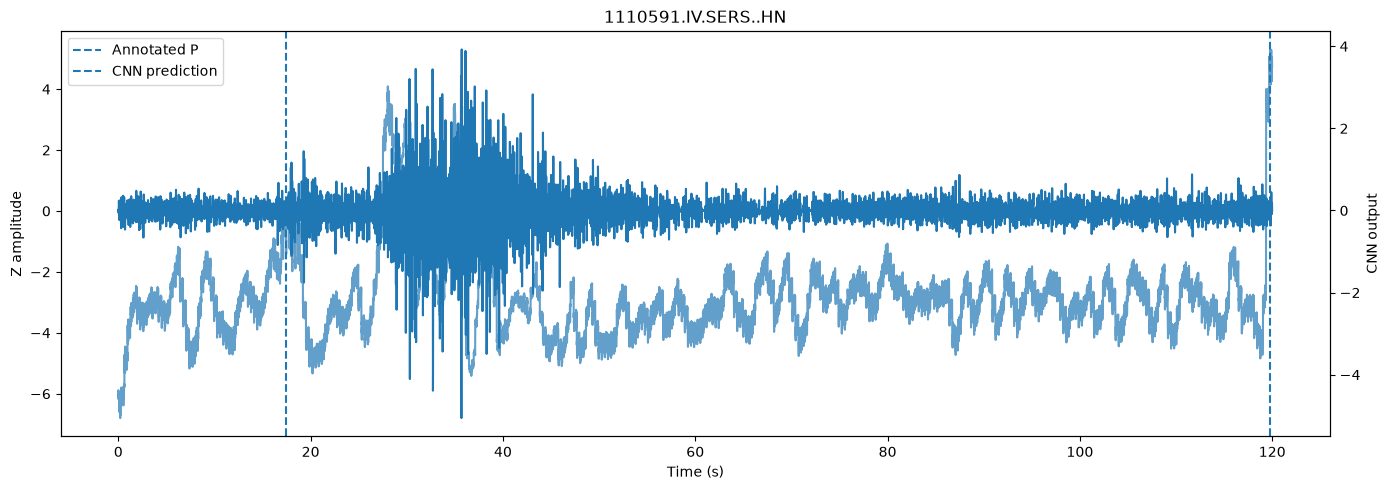

In [104]:
import matplotlib.pyplot as plt
import torch
import numpy as np

annotated_p_sample = int(worst_5.iloc[0]["annotated_p_sample"])
predicted_p_sample = int(worst_5.iloc[0]["predicted_p_sample"])

z_waveform = waveform[2]

waveform_tensor = torch.tensor(
    waveform,
    dtype=torch.float32
).unsqueeze(0).to(device)

with torch.no_grad():
    logits = model(waveform_tensor)

cnn_output = logits.squeeze(0).cpu().numpy()

time = np.arange(len(z_waveform)) / 100.0

fig, ax1 = plt.subplots(figsize=(14, 5))

ax1.plot(time, z_waveform)
ax1.axvline(
    annotated_p_sample / 100.0,
    linestyle="--",
    label="Annotated P"
)
ax1.axvline(
    predicted_p_sample / 100.0,
    linestyle="--",
    label="CNN prediction"
)

ax1.set_xlabel("Time (s)")
ax1.set_ylabel("Z amplitude")
ax1.set_title(worst_5.iloc[0]["trace_name"])
ax1.legend()

ax2 = ax1.twinx()
ax2.plot(time, cnn_output, alpha=0.7)
ax2.set_ylabel("CNN output")

plt.tight_layout()
plt.show()

## Check for systematic end-of-trace CNN responses

The CNN output near the end of the validation waveforms is examined across multiple traces to determine whether the late predictions are systematic.

In [105]:
# Examine the 20 worst validation traces
check_rows = worst_5.copy()

for _, row in check_rows.iterrows():
    trace_name = row["trace_name"]

    with h5py.File(val_processed_path, "r") as f:
        stored_names = np.array([
            name.decode() if isinstance(name, bytes) else str(name)
            for name in f["trace_name"][:]
        ])

        idx = np.where(stored_names == trace_name)[0][0]
        waveform_check = f["waveforms"][idx]

    x = torch.tensor(
        waveform_check,
        dtype=torch.float32
    ).unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(x).squeeze(0).cpu().numpy()

    print(
        f"{trace_name} | "
        f"true={row['annotated_p_time_s']:.2f}s | "
        f"pred={row['predicted_p_time_s']:.2f}s | "
        f"max output={output.max():.3f} | "
        f"last sample={output[-1]:.3f}"
    )

1110591.IV.SERS..HN | true=17.43s | pred=119.81s | max output=3.923 | last sample=3.513
11121911.ST.GAGG..HN | true=18.05s | pred=119.79s | max output=2.513 | last sample=2.238
11265021.IV.FIAM..HN | true=18.85s | pred=119.90s | max output=3.666 | last sample=3.254
11215531.IV.T1245..HH | true=16.50s | pred=117.38s | max output=4.209 | last sample=-5.044
1123771.IV.FIAM..HN | true=19.80s | pred=119.81s | max output=4.010 | last sample=3.607


## Diagnose boundary-related P-wave picks

Predictions are recomputed while excluding the final 2 seconds of the CNN output. This diagnostic checks whether late-boundary responses account for a substantial portion of the large timing errors.

In [106]:
diagnostic_pred_samples = []

cutoff = 12000 - 200   # exclude final 2 seconds

with torch.no_grad():
    for waveforms, _ in val_loader:
        waveforms = waveforms.to(device)

        logits = model(waveforms)
        logits[:, cutoff:] = -torch.inf

        predicted_samples = torch.argmax(logits, dim=1)

        diagnostic_pred_samples.extend(
            predicted_samples.cpu().numpy()
        )

diagnostic_pred_samples = np.array(diagnostic_pred_samples)

diagnostic_errors = (
    np.abs(
        diagnostic_pred_samples
        - val_metadata["trace_P_arrival_sample"].values.astype(int)
    ) / 100.0
)

print(f"Mean absolute error:   {diagnostic_errors.mean():.4f} s")
print(f"Median absolute error: {np.median(diagnostic_errors):.4f} s")
print(f"Within ±0.5 s:         {(diagnostic_errors <= 0.5).mean()*100:.2f}%")
print(f"Within ±1.0 s:         {(diagnostic_errors <= 1.0).mean()*100:.2f}%")
print(f"Within ±2.0 s:         {(diagnostic_errors <= 2.0).mean()*100:.2f}%")

Mean absolute error:   5.0061 s
Median absolute error: 0.1100 s
Within ±0.5 s:         80.35%
Within ±1.0 s:         83.30%
Within ±2.0 s:         85.06%


## Analyze predicted P-wave arrival locations

The distribution of CNN-predicted arrival times is compared with the distribution of annotated P-wave arrival times to identify systematic localization errors.

In [107]:
predicted_times = predicted_p_samples / 100.0
annotated_times = (
    val_metadata["trace_P_arrival_sample"].values.astype(int) / 100.0
)

print(
    f"Predicted arrival time: "
    f"mean={predicted_times.mean():.2f}s, "
    f"median={np.median(predicted_times):.2f}s"
)

print(
    f"Annotated arrival time: "
    f"mean={annotated_times.mean():.2f}s, "
    f"median={np.median(annotated_times):.2f}s"
)

print("\nPrediction time percentiles:")
for q in [0.50, 0.75, 0.90, 0.95, 0.99]:
    print(f"{q*100:.0f}th percentile: {np.quantile(predicted_times, q):.2f}s")

print("\nPredictions after 60 s:",
      (predicted_times > 60).sum())

print("Predictions after 100 s:",
      (predicted_times > 100).sum())

Predicted arrival time: mean=25.25s, median=19.30s
Annotated arrival time: mean=20.79s, median=19.01s

Prediction time percentiles:
50th percentile: 19.30s
75th percentile: 21.66s
90th percentile: 40.72s
95th percentile: 75.91s
99th percentile: 115.87s

Predictions after 60 s: 103
Predictions after 100 s: 34


## Compare the true-P CNN response with the selected peak

The CNN output at the annotated P arrival is compared with its global maximum. This determines whether the model has learned the P-wave location but produces competing false peaks elsewhere.

In [108]:
# Examine the 20 worst validation predictions

for _, row in worst_5.iterrows():
    trace_name = row["trace_name"]

    with h5py.File(val_processed_path, "r") as f:
        stored_names = np.array([
            name.decode() if isinstance(name, bytes) else str(name)
            for name in f["trace_name"][:]
        ])

        idx = np.where(stored_names == trace_name)[0][0]
        waveform_check = f["waveforms"][idx]

    x = torch.tensor(
        waveform_check,
        dtype=torch.float32
    ).unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(x).squeeze(0).cpu().numpy()

    true_sample = int(row["annotated_p_sample"])
    pred_sample = int(row["predicted_p_sample"])

    # Highest output in a ±1 second region around annotated P
    local_start = max(0, true_sample - 100)
    local_end = min(12000, true_sample + 100)

    local_max = output[local_start:local_end].max()
    local_max_sample = (
        local_start + np.argmax(output[local_start:local_end])
    )

    global_max = output.max()

    print(
        f"{trace_name} | "
        f"true={true_sample/100:.2f}s | "
        f"pred={pred_sample/100:.2f}s | "
        f"P-region peak={local_max:.3f} "
        f"at {local_max_sample/100:.2f}s | "
        f"global peak={global_max:.3f}"
    )

1110591.IV.SERS..HN | true=17.43s | pred=119.81s | P-region peak=0.375 at 17.71s | global peak=3.923
11121911.ST.GAGG..HN | true=18.05s | pred=119.79s | P-region peak=0.647 at 18.33s | global peak=2.513
11265021.IV.FIAM..HN | true=18.85s | pred=119.90s | P-region peak=1.369 at 18.58s | global peak=3.666
11215531.IV.T1245..HH | true=16.50s | pred=117.38s | P-region peak=3.872 at 16.35s | global peak=4.209
1123771.IV.FIAM..HN | true=19.80s | pred=119.81s | P-region peak=1.163 at 19.22s | global peak=4.010


## Test earliest-strong-peak P-wave picking

The earliest peak exceeding a fraction of the maximum CNN response is selected instead of the global maximum. Several threshold fractions are compared on the validation set.

In [109]:
from scipy.signal import find_peaks

thresholds = [0.10, 0.20, 0.30, 0.40, 0.50]

validation_outputs = []
validation_true_samples = []

with torch.no_grad():
    for waveforms, _ in val_loader:
        waveforms = waveforms.to(device)

        logits = model(waveforms)
        validation_outputs.extend(
            logits.cpu().numpy()
        )

validation_outputs = np.asarray(validation_outputs)

validation_true_samples = (
    val_metadata["trace_P_arrival_sample"]
    .values
    .astype(int)
)

for threshold_fraction in thresholds:

    predicted_samples = []

    for output in validation_outputs:

        max_value = output.max()
        threshold = threshold_fraction * max_value

        peaks, properties = find_peaks(
            output,
            height=threshold,
            distance=50
        )

        if len(peaks) > 0:
            predicted_sample = peaks[0]
        else:
            predicted_sample = np.argmax(output)

        predicted_samples.append(predicted_sample)

    predicted_samples = np.asarray(predicted_samples)

    errors = (
        np.abs(predicted_samples - validation_true_samples)
        / 100.0
    )

    print(
        f"Threshold {threshold_fraction:.2f} | "
        f"MAE={errors.mean():.3f}s | "
        f"Median={np.median(errors):.3f}s | "
        f"±0.5s={(errors <= 0.5).mean()*100:.2f}% | "
        f"±1.0s={(errors <= 1.0).mean()*100:.2f}% | "
        f"±2.0s={(errors <= 2.0).mean()*100:.2f}%"
    )

Threshold 0.10 | MAE=10.300s | Median=10.330s | ±0.5s=15.07% | ±1.0s=32.20% | ±2.0s=36.22%
Threshold 0.20 | MAE=8.178s | Median=2.980s | ±0.5s=24.92% | ±1.0s=44.13% | ±2.0s=47.71%
Threshold 0.30 | MAE=6.540s | Median=0.680s | ±0.5s=34.53% | ±1.0s=55.12% | ±2.0s=57.88%
Threshold 0.40 | MAE=5.169s | Median=0.540s | ±0.5s=46.14% | ±1.0s=64.28% | ±2.0s=67.42%
Threshold 0.50 | MAE=3.977s | Median=0.440s | ±0.5s=57.25% | ±1.0s=72.25% | ±2.0s=75.02%


## Optimize an absolute CNN-output threshold

The earliest local CNN peak above a fixed output threshold is evaluated on the validation set. The threshold is varied to identify a stable P-wave picking criterion.

In [110]:
absolute_thresholds = [0.25, 0.50, 0.75, 1.00, 1.25, 1.50, 2.00, 2.50, 3.00]

for threshold in absolute_thresholds:

    predicted_samples = []

    for output in validation_outputs:

        peaks, properties = find_peaks(
            output,
            height=threshold,
            distance=50
        )

        if len(peaks) > 0:
            predicted_sample = peaks[0]
        else:
            predicted_sample = np.argmax(output)

        predicted_samples.append(predicted_sample)

    predicted_samples = np.asarray(predicted_samples)

    errors = (
        np.abs(predicted_samples - validation_true_samples)
        / 100.0
    )

    print(
        f"Threshold {threshold:.2f} | "
        f"MAE={errors.mean():.3f}s | "
        f"Median={np.median(errors):.3f}s | "
        f"±0.5s={(errors <= 0.5).mean()*100:.2f}% | "
        f"±1.0s={(errors <= 1.0).mean()*100:.2f}% | "
        f"±2.0s={(errors <= 2.0).mean()*100:.2f}%"
    )

Threshold 0.25 | MAE=11.388s | Median=12.600s | ±0.5s=11.42% | ±1.0s=26.43% | ±2.0s=30.70%
Threshold 0.50 | MAE=10.381s | Median=10.390s | ±0.5s=15.07% | ±1.0s=32.02% | ±2.0s=36.03%
Threshold 0.75 | MAE=9.548s | Median=7.360s | ±0.5s=19.15% | ±1.0s=36.97% | ±2.0s=40.80%
Threshold 1.00 | MAE=8.601s | Median=4.140s | ±0.5s=23.10% | ±1.0s=42.44% | ±2.0s=46.33%
Threshold 1.25 | MAE=7.353s | Median=1.010s | ±0.5s=28.06% | ±1.0s=49.97% | ±2.0s=53.30%
Threshold 1.50 | MAE=6.422s | Median=0.650s | ±0.5s=33.21% | ±1.0s=56.50% | ±2.0s=60.14%
Threshold 2.00 | MAE=5.379s | Median=0.540s | ±0.5s=45.26% | ±1.0s=65.85% | ±2.0s=68.55%
Threshold 2.50 | MAE=4.925s | Median=0.450s | ±0.5s=55.93% | ±1.0s=71.19% | ±2.0s=73.63%
Threshold 3.00 | MAE=4.194s | Median=0.260s | ±0.5s=66.04% | ±1.0s=76.08% | ±2.0s=78.72%


## Refine the CNN P-wave picking threshold

Higher absolute CNN-output thresholds are evaluated on the validation set to determine whether the reduction in large timing errors continues.

In [111]:
for threshold in [3.5, 4.0, 4.5, 5.0, 6.0]:

    predicted_samples = []

    for output in validation_outputs:

        peaks, properties = find_peaks(
            output,
            height=threshold,
            distance=50
        )

        if len(peaks) > 0:
            predicted_sample = peaks[0]
        else:
            predicted_sample = np.argmax(output)

        predicted_samples.append(predicted_sample)

    predicted_samples = np.asarray(predicted_samples)

    errors = (
        np.abs(
            predicted_samples - validation_true_samples
        ) / 100.0
    )

    print(
        f"Threshold {threshold:.2f} | "
        f"MAE={errors.mean():.3f}s | "
        f"Median={np.median(errors):.3f}s | "
        f"±0.5s={(errors <= 0.5).mean()*100:.2f}% | "
        f"±1.0s={(errors <= 1.0).mean()*100:.2f}% | "
        f"±2.0s={(errors <= 2.0).mean()*100:.2f}%"
    )

Threshold 3.50 | MAE=4.106s | Median=0.140s | ±0.5s=73.07% | ±1.0s=78.53% | ±2.0s=80.67%
Threshold 4.00 | MAE=4.530s | Median=0.120s | ±0.5s=78.78% | ±1.0s=82.23% | ±2.0s=84.12%
Threshold 4.50 | MAE=5.179s | Median=0.110s | ±0.5s=80.04% | ±1.0s=83.11% | ±2.0s=84.68%
Threshold 5.00 | MAE=5.388s | Median=0.110s | ±0.5s=79.97% | ±1.0s=82.99% | ±2.0s=84.68%
Threshold 6.00 | MAE=5.593s | Median=0.110s | ±0.5s=79.85% | ±1.0s=82.80% | ±2.0s=84.49%


## Evaluate the final Stage 2 CNN P-wave picker

The P-wave picking rule selected on the validation set is fixed at an absolute CNN-output threshold of 4.0. The rule is applied once to the held-out test set.

In [112]:
# Collect test-set CNN outputs

test_outputs = []

with torch.no_grad():
    for waveforms, _ in test_loader:
        waveforms = waveforms.to(device)

        logits = model(waveforms)

        test_outputs.extend(
            logits.cpu().numpy()
        )

test_outputs = np.asarray(test_outputs)

test_true_samples = (
    test_metadata["trace_P_arrival_sample"]
    .values
    .astype(int)
)

# Final frozen picking threshold
final_threshold = 4.0

test_predicted_samples = []

for output in test_outputs:

    peaks, properties = find_peaks(
        output,
        height=final_threshold,
        distance=50
    )

    if len(peaks) > 0:
        predicted_sample = peaks[0]
    else:
        predicted_sample = np.argmax(output)

    test_predicted_samples.append(predicted_sample)

test_predicted_samples = np.asarray(test_predicted_samples)

test_errors = (
    np.abs(
        test_predicted_samples - test_true_samples
    ) / 100.0
)

print(f"Mean absolute error:   {test_errors.mean():.4f} s")
print(f"Median absolute error: {np.median(test_errors):.4f} s")
print(f"Within ±0.1 s:         {(test_errors <= 0.1).mean()*100:.2f}%")
print(f"Within ±0.5 s:         {(test_errors <= 0.5).mean()*100:.2f}%")
print(f"Within ±1.0 s:         {(test_errors <= 1.0).mean()*100:.2f}%")
print(f"Within ±2.0 s:         {(test_errors <= 2.0).mean()*100:.2f}%")

Mean absolute error:   4.9452 s
Median absolute error: 0.1100 s
Within ±0.1 s:         49.15%
Within ±0.5 s:         82.02%
Within ±1.0 s:         83.96%
Within ±2.0 s:         84.99%


## Save final Stage 2 CNN picking results

The held-out test predictions and timing errors are saved for comparison with the traditional STA/LTA P-wave picker.

In [114]:
stage2_cnn_results = pd.DataFrame({
    "trace_name": test_metadata["trace_name"].values,
    "source_id": test_metadata["source_id"].values,
    "annotated_p_sample": test_true_samples,
    "predicted_p_sample": test_predicted_samples,
    "annotated_p_time_s": test_true_samples / 100.0,
    "predicted_p_time_s": test_predicted_samples / 100.0,
    "abs_error_s": test_errors
})

output_path = "../results/metrics/stage2_cnn_picking.csv"

stage2_cnn_results.to_csv(output_path, index=False)

print(f"Saved: {output_path}")
print(f"Rows: {len(stage2_cnn_results)}")

Saved: ../results/metrics/stage2_cnn_picking.csv
Rows: 1646


## Final Stage 2 model comparison

The final held-out test performance of the traditional STA/LTA picker and the 1D CNN picker is compared using P-wave arrival-time error metrics.

In [115]:
stage2_comparison = pd.DataFrame({
    "Model": [
        "STA/LTA",
        "1D CNN"
    ],
    "MAE_s": [
        2.7246,
        4.9452
    ],
    "Median_error_s": [
        0.2500,
        0.1100
    ],
    "Within_0.1s_pct": [
        30.78,
        49.15
    ],
    "Within_0.5s_pct": [
        63.42,
        82.02
    ],
    "Within_1.0s_pct": [
        72.15,
        83.96
    ],
    "Within_2.0s_pct": [
        76.42,
        84.99
    ]
})

stage2_comparison

,Model,MAE_s,Median_error_s,Within_0.1s_pct,Within_0.5s_pct,Within_1.0s_pct,Within_2.0s_pct
0,STA/LTA,2.7246,0.25,30.78,63.42,72.15,76.42
1,1D CNN,4.9452,0.11,49.15,82.02,83.96,84.99
